Projekt Dyplomowy 331720




ETAP 1- WCZYTANIE DANYCH I WIZUALIZACJA

In [79]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

In [80]:
ticker = ("BTC-USD")  # <- zmień na dowolny symbol, np. "AAPL", "^GSPC", "ETH-USD"
okres  = "2y"       # <- 1d, 5d, 1mo, 3mo, 6mo, 1y, 2y, 5y, 10y, ytd, max
interwal = "1d"     # <- 1m, 5m, 15m, 1h, 1d, 1wk, 1mo

In [94]:
df = yf.download(ticker, period=okres, interval=interwal)
df.columns = df.columns.get_level_values(0) #usuniecie podowojnych naglowkow
df = df.reset_index() #Date jako kolumna a nie indeks
df.columns.name = None #usunięcie price zeby tabela wygladala czysto

[*********************100%***********************]  1 of 1 completed


In [95]:
print(df.head())

        Date         Close          High           Low          Open  \
0 2024-03-18  67548.593750  68897.132812  66594.226562  68371.304688   
1 2024-03-19  61912.773438  68106.929688  61536.179688  67556.132812   
2 2024-03-20  67913.671875  68115.257812  60807.785156  61930.156250   
3 2024-03-21  65491.390625  68199.992188  64580.917969  67911.585938   
4 2024-03-22  63778.761719  66623.750000  62355.371094  65489.929688   

        Volume  
0  49261579492  
1  74215844794  
2  66792634382  
3  44480350565  
4  41401116964  


Open- cena otwarcia świecy

High — najwyższa cena w ciągu dnia

Low — najniższa cena w ciągu dnia

Close — cena zamknięcia świecy (na końcu dnia)

Volume — wolumen, czyli ile BTC zostało sprzedane w ciągu dnia

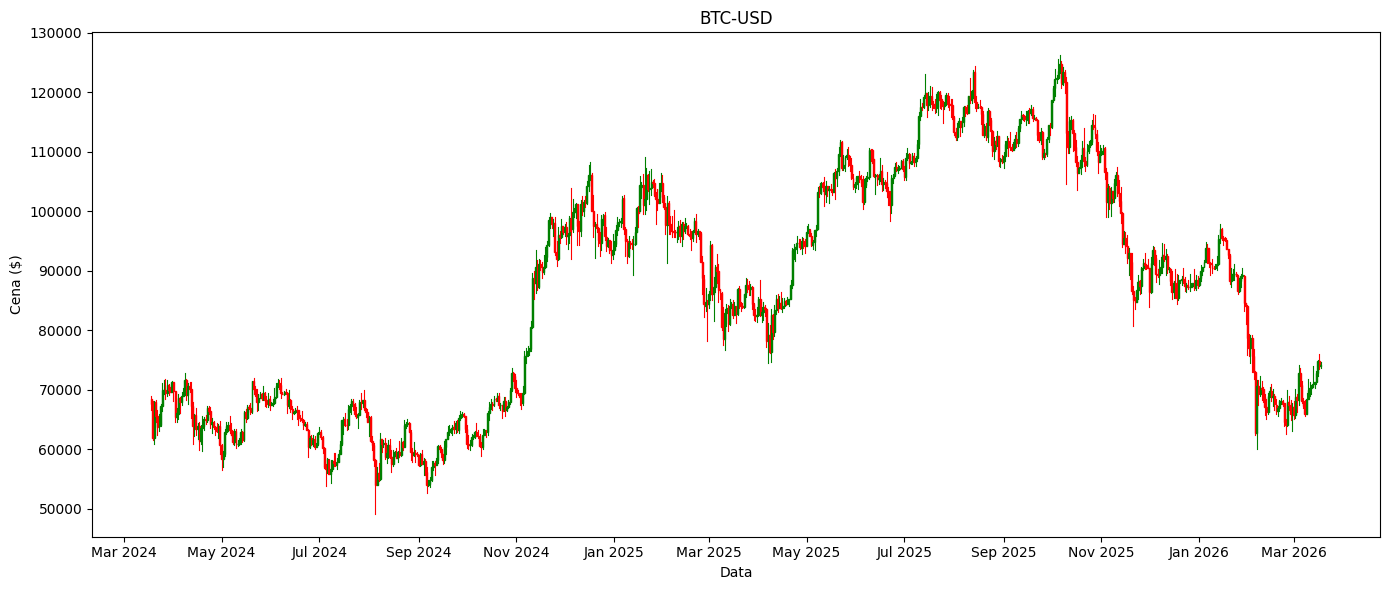

In [98]:
fig, ax = plt.subplots(figsize=(14, 6))

for _, row in df.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.plot([row["Date"], row["Date"]], [row["Low"], row["High"]], color=color, linewidth=0.8) #knot siwecy
    ax.add_patch(Rectangle(     #swieca
        (mdates.date2num(row["Date"]) - 0.3, min(row["Open"], row["Close"])),
        0.6,
        abs(row["Close"] - row["Open"]),
        color=color
    ))

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))    # etykiety osi x na daty
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))     # co 2 miesiace etykieta na osi x
plt.title(f"{ticker}")
plt.xlabel("Data")
plt.ylabel("Cena ($)")
plt.tight_layout()
plt.show()